In [1]:
import skimage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
dir = '/scr/yren/mask_correction/hela_rpe_masks_check/'
gt_dir = '/scr/yren/all_data_micronuclei/'
preds = os.listdir(dir)
df = pd.read_csv(gt_dir + 'metadata.csv')

In [5]:
df[df.datasets.isin(['mnfinder_train', 'mnfinder_validation'])]

,filenames,datasets,magnification,micron,split
24,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
25,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
26,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
27,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
28,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train
29,2022-03-18_RPE1-4.phenotype.tif,mnfinder_train,20,11.0,train
30,2022-05-26_RPE1-2.phenotype.tif,mnfinder_train,20,11.0,train
31,2022-05-26_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
32,2023-05-31_misc-10.phenotype.tif,mnfinder_train,20,11.0,train
33,2023-05-31_misc-11.phenotype.tif,mnfinder_train,20,11.0,train


In [11]:
hela_rpe = df[df.datasets.isin(['HeLa', 'RPE1'])]
hela_rpe

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
5,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5,test


In [13]:
hela_rpe.iloc[0].split

'train'

In [17]:
gts = []
inputs = []
for i in range(6):
    gt_path = gt_dir + hela_rpe.iloc[i].split + '/' + hela_rpe.iloc[i].filenames.replace('phenotype.tif', 'phenotype_outlines.png')
    gts.append(gt_path)
    
    input_path = gt_dir + hela_rpe.iloc[i].split + '/' + hela_rpe.iloc[i].filenames
    inputs.append(input_path)
print(gts)
print(inputs)

['/scr/yren/all_data_micronuclei/train/C1-20X_c0_B3_Tile-5.phenotype_outlines.png', '/scr/yren/all_data_micronuclei/validation/C1-20X_c0_B3_Tile-24.phenotype_outlines.png', '/scr/yren/all_data_micronuclei/test/C1-20X_c0_B3_Tile-15.phenotype_outlines.png', '/scr/yren/all_data_micronuclei/train/C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png', '/scr/yren/all_data_micronuclei/validation/C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png', '/scr/yren/all_data_micronuclei/test/C1-20X_c0_phalloidin_C3_Tile-44.phenotype_outlines.png']
['/scr/yren/all_data_micronuclei/train/C1-20X_c0_B3_Tile-5.phenotype.tif', '/scr/yren/all_data_micronuclei/validation/C1-20X_c0_B3_Tile-24.phenotype.tif', '/scr/yren/all_data_micronuclei/test/C1-20X_c0_B3_Tile-15.phenotype.tif', '/scr/yren/all_data_micronuclei/train/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif', '/scr/yren/all_data_micronuclei/validation/C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif', '/scr/yren/all_data_micronuclei/test/C1-20X_c0_ph

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


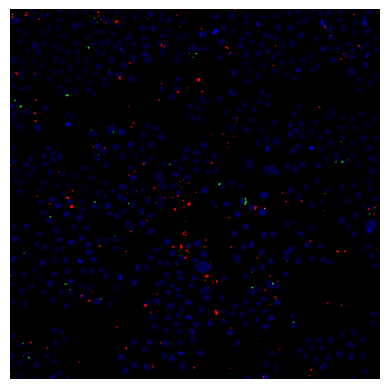

/tmp/ipykernel_1572273/2346649255.py:12: UserWarning: /scr/yren/mask_correction/prediction_corrections/C1-20X_c0_B3_Tile-5.overlaps.tif is a low contrast image
  skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


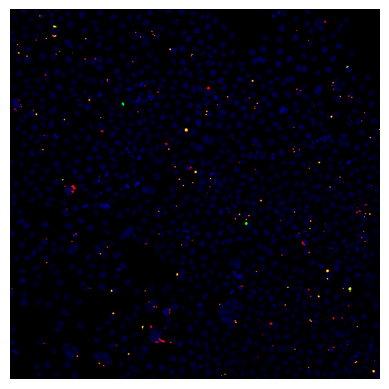

/tmp/ipykernel_1572273/2346649255.py:12: UserWarning: /scr/yren/mask_correction/prediction_corrections/C1-20X_c0_B3_Tile-24.overlaps.tif is a low contrast image
  skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


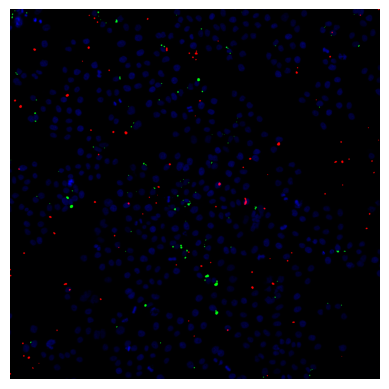

/tmp/ipykernel_1572273/2346649255.py:12: UserWarning: /scr/yren/mask_correction/prediction_corrections/C1-20X_c0_B3_Tile-15.overlaps.tif is a low contrast image
  skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


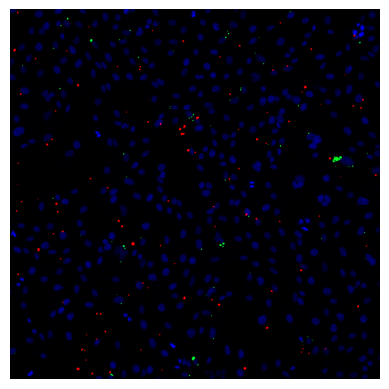

/tmp/ipykernel_1572273/2346649255.py:12: UserWarning: /scr/yren/mask_correction/prediction_corrections/C1-20X_c0_phalloidin_C3_Tile-18.overlaps.tif is a low contrast image
  skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


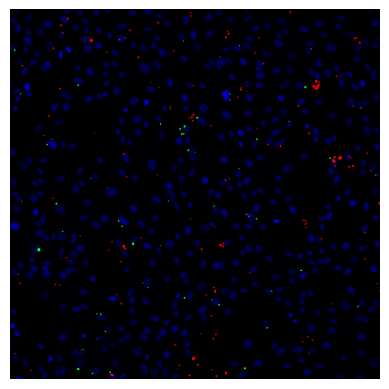

/tmp/ipykernel_1572273/2346649255.py:12: UserWarning: /scr/yren/mask_correction/prediction_corrections/C1-20X_c0_phalloidin_C3_Tile-15.overlaps.tif is a low contrast image
  skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


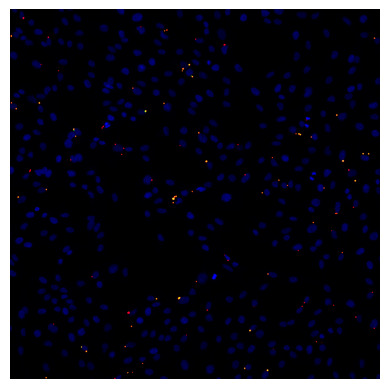

/tmp/ipykernel_1572273/2346649255.py:12: UserWarning: /scr/yren/mask_correction/prediction_corrections/C1-20X_c0_phalloidin_C3_Tile-44.overlaps.tif is a low contrast image
  skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)


In [39]:
for i in range(6):
    input = skimage.io.imread(inputs[i])
    pred = np.load(dir + preds[i])
    gt = skimage.io.imread(gts[i])
    overlap = np.concatenate([255*(pred > 0)[:,:,None], 255 * (gt > 0)[:,:,None], 1.*input[:,:,None]], axis=2)
    # print(np.unique(pred))
    # print(np.unique(gt))
    plt.imshow(overlap)
    plt.axis('off')
    plt.show()
    imid = inputs[i].split('/')[-1].split('.')[0]
    skimage.io.imsave(f'/scr/yren/mask_correction/prediction_corrections/{imid}.overlaps.tif', overlap)
plt.close()

- Verify the save images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2992, 2992, 3)


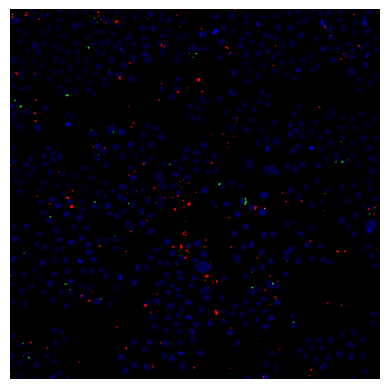

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2992, 2992, 3)


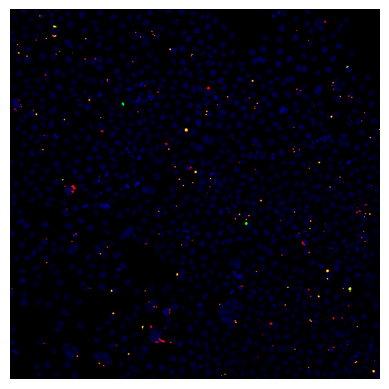

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2992, 2992, 3)


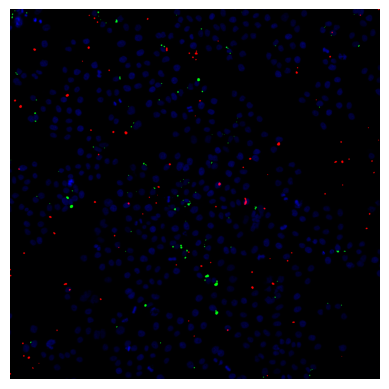

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2992, 2992, 3)


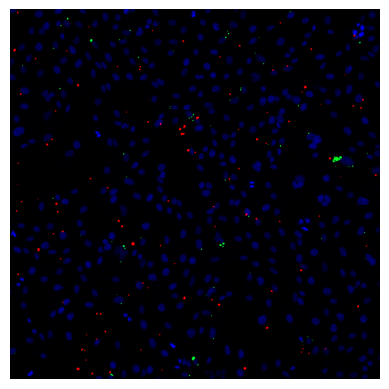

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2992, 2992, 3)


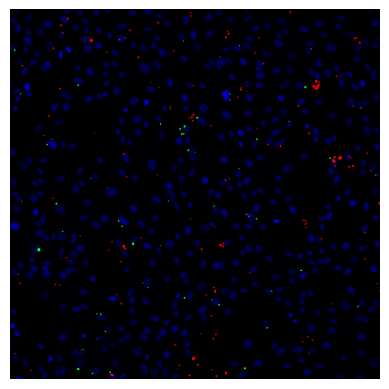

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2992, 2992, 3)


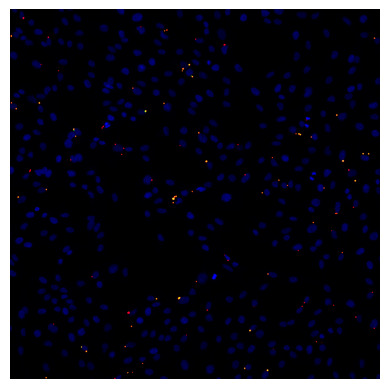

In [43]:
path = '/scr/yren/mask_correction/prediction_corrections/'
files = os.listdir(path)

for i in range(len(files)):
    im = skimage.io.imread(path + files[i])
    print(im.shape)
    plt.imshow(im)
    plt.axis('off')
    plt.show()
plt.close()